In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
from snntorch import utils
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import time

# --- 1. Simulation & Physics Parameters ---
fs = 10000        # Sampling Rate (Hz)
T = 0.2           # Duration (s)
t_vec = torch.linspace(0, T, int(fs*T))
time_steps = len(t_vec)

# Physics
c = 343.0         # Speed of sound (m/s)
min_dist = 1.0
max_dist = 10.0

# Radar Waveform (Pre-computed)
chirp_duration = 0.005
bw = 2000
f_start = 500
f_carrier = 4000
t_chirp_np = np.linspace(0, chirp_duration, int(fs*chirp_duration))
chirp_template_np = signal.chirp(t_chirp_np, f0=f_start, f1=f_start+bw, t1=chirp_duration, method='linear')
carrier_np = np.cos(2 * np.pi * f_carrier * t_vec.numpy())
sos_filter = signal.butter(10, f_carrier, 'low', fs=fs, output='sos')
matched_filter = chirp_template_np[::-1]

# SNN Params
batch_size = 32
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# --- 2. The Data Generation Function ---
def generate_batch_regression(batch_size):
    """
    Generates a batch of training data for REGRESSION.
    Labels are now continuous floats (Distances), not integers.
    """
    # Output tensors
    batch_sent_spikes = torch.zeros(time_steps, batch_size)
    batch_recv_spikes = torch.zeros(time_steps, batch_size)
    batch_targets = torch.zeros(batch_size, 1) # Continuous targets

    # 1. SNN Transmitter (Stochastic Source)
    tx_lif = snn.Leaky(beta=0.9, threshold=1.0)
    tx_mem = tx_lif.init_leaky()
    sent_spikes = torch.zeros(time_steps)
    # Generate ONE unique pulse train for this batch
    # (In reality, the bat changes pulses, but for stable training we use one 'chirp' type)
    tx_current = 0.05 * torch.ones(time_steps)
    for t in range(time_steps):
        spk, tx_mem = tx_lif(tx_current[t], tx_mem)
        sent_spikes[t] = spk
    
    # RF Modulation
    baseband_np = signal.convolve(sent_spikes.numpy(), chirp_template_np, mode='same')
    tx_signal_np = baseband_np * carrier_np

    # 2. Simulate Channel & Receiver per sample
    lif_encoder = snn.Leaky(beta=0.8, threshold=0.5) # Sensitive encoder

    for i in range(batch_size):
        # Random Distance (Continuous)
        dist = np.random.uniform(min_dist, max_dist)
        batch_targets[i] = dist # The Label is the Distance
        
        # Physics (Delay)
        tof = (2 * dist) / c
        delay_samples = int(tof * fs)
        
        rx_signal = np.roll(tx_signal_np, delay_samples)
        rx_signal *= (1.0 / (dist**0.5 + 1)) # Inverse distance attenuation
        rx_signal += np.random.normal(0, 0.1, len(rx_signal)) # Noise
        
        # Receiver Processing
        demod = rx_signal * carrier_np
        baseband = signal.sosfilt(sos_filter, demod)
        matched = signal.convolve(baseband, matched_filter, mode='same')
        
        # Re-Encoding to Spikes
        matched_norm = (matched - matched.min()) / (matched.max() - matched.min() + 1e-6)
        matched_tensor = torch.tensor(matched_norm).float()
        
        enc_mem = lif_encoder.init_leaky()
        recv_spikes_i = torch.zeros(time_steps)
        for t in range(time_steps):
            spk, enc_mem = lif_encoder(matched_tensor[t], enc_mem)
            recv_spikes_i[t] = spk
            
        batch_sent_spikes[:, i] = sent_spikes
        batch_recv_spikes[:, i] = recv_spikes_i
        
    return batch_sent_spikes.to(device), batch_recv_spikes.to(device), batch_targets.to(device)

# --- 3. The "Physically Initialized" SNN Regressor ---
class RadarRegressionSNN(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        
        self.hidden_size = hidden_size

        # --- PHYSICAL BASIS INITIALIZATION 1: Heterogeneous Time Constants ---
        # Biological neurons are not identical. They have a diverse range of 
        # time constants (tau). This diversity allows a population to capture 
        # information at different time scales (short delays vs long delays).
        # We initialize beta linearly from fast (0.5) to slow (0.98).
        beta_distribution = torch.linspace(0.5, 0.98, hidden_size)
        
        # Make beta a learnable parameter, but start with this "Physical Basis"
        self.beta_hidden = nn.Parameter(beta_distribution)
        
        # Surrogate Gradient for backprop
        spike_grad = surrogate.fast_sigmoid(slope=25)
        
        # Layers
        self.fc1 = nn.Linear(2, hidden_size) # Inputs: [Sent, Recv]
        self.lif1 = snn.Leaky(beta=self.beta_hidden, spike_grad=spike_grad, learn_beta=True)
        
        self.fc2 = nn.Linear(hidden_size, 1) # Output: 1 continuous value
        
        # --- OUTPUT NEURON: Non-Spiking Leaky Integrator ---
        # For regression, we don't want spikes output. We want the membrane voltage.
        # We set reset_mechanism="none" so it acts as a voltage accumulator.
        self.lif_out = snn.Leaky(beta=0.95, spike_grad=spike_grad, 
                                 reset_mechanism="none", output=True)

    def forward(self, sent, recv):
        # Inputs shape: [Time, Batch] -> We process time step by step
        
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif_out.init_leaky()
        
        # Record the output voltage trace
        out_voltage_rec = []
        
        for t in range(sent.shape[0]):
            # Combine inputs [Batch, 2]
            x = torch.stack([sent[t], recv[t]], dim=1)
            
            # Hidden Layer
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            
            # Output Layer (Accumulate Voltage)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif_out(cur2, mem2)
            
            # We only care about the final accumulated voltage, 
            # but we could record it over time if needed.
        
        # The prediction is the FINAL voltage of the output neuron
        return mem2

# --- 4. Training Loop (MSE Loss) ---
hidden_size = 64
model = RadarRegressionSNN(hidden_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
loss_fn = nn.MSELoss() # Mean Squared Error for Regression

print("--- Starting Physically-Initialized SNN Training ---")
loss_history = []

# Training params
epochs = 15
batches_per_epoch = 20 

for epoch in range(epochs):
    epoch_loss = 0
    for b in range(batches_per_epoch):
        # 1. Generate Data
        s, r, targets = generate_batch_regression(batch_size)
        
        # 2. Forward Pass
        optimizer.zero_grad()
        predicted_dist = model(s, r)
        
        # 3. Calculate MSE Loss
        loss = loss_fn(predicted_dist, targets)
        
        # 4. Backprop
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss/batches_per_epoch
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}: MSE Loss = {avg_loss:.4f} | RMSE = {np.sqrt(avg_loss):.2f} m")

# --- 5. Evaluation & Visualization ---
print("\n--- Testing ---")
# Generate a test batch (sorted by distance for nice plotting)
test_batch = 50
s_test, r_test, t_test = generate_batch_regression(test_batch)

# Sort for plotting
sorted_indices = torch.argsort(t_test.flatten())
s_test = s_test[:, sorted_indices]
r_test = r_test[:, sorted_indices]
t_test = t_test[sorted_indices]

with torch.no_grad():
    preds = model(s_test, r_test)

# Convert to numpy
t_np = t_test.cpu().numpy().flatten()
p_np = preds.cpu().numpy().flatten()

--- Starting Physically-Initialized SNN Training ---
Epoch 1: MSE Loss = 12.4400 | RMSE = 3.53 m
Epoch 2: MSE Loss = 7.5598 | RMSE = 2.75 m
Epoch 3: MSE Loss = 6.5481 | RMSE = 2.56 m
Epoch 4: MSE Loss = 7.0365 | RMSE = 2.65 m
Epoch 5: MSE Loss = 6.3745 | RMSE = 2.52 m
Epoch 6: MSE Loss = 6.8550 | RMSE = 2.62 m
Epoch 7: MSE Loss = 7.1642 | RMSE = 2.68 m
Epoch 8: MSE Loss = 6.9021 | RMSE = 2.63 m
Epoch 9: MSE Loss = 6.5912 | RMSE = 2.57 m
Epoch 10: MSE Loss = 6.5493 | RMSE = 2.56 m
Epoch 11: MSE Loss = 7.0105 | RMSE = 2.65 m
Epoch 12: MSE Loss = 6.7065 | RMSE = 2.59 m
Epoch 13: MSE Loss = 6.6764 | RMSE = 2.58 m
Epoch 14: MSE Loss = 6.4107 | RMSE = 2.53 m
Epoch 15: MSE Loss = 6.1845 | RMSE = 2.49 m

--- Testing ---


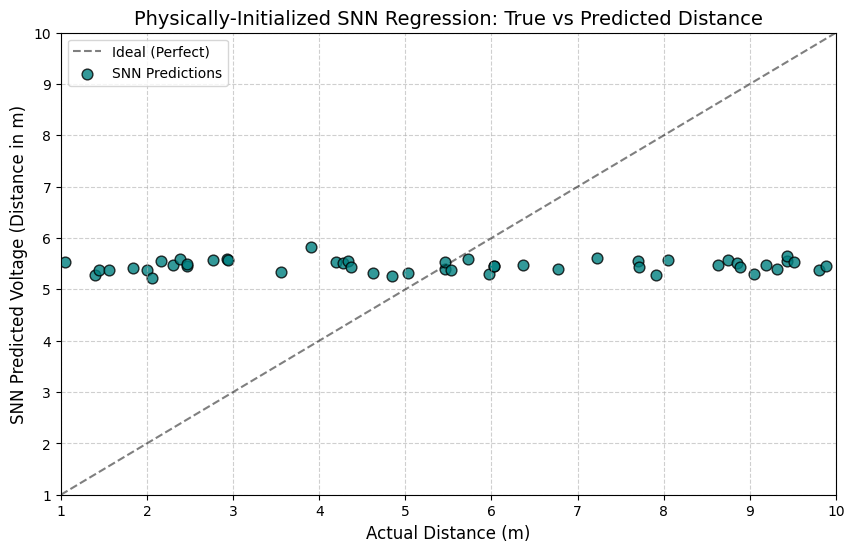

In [2]:


import matplotlib.pyplot as plt

# Create the comparison plot
plt.figure(figsize=(10, 6))

# 1. Ideal Line (Perfect Prediction)
plt.plot([min_dist, max_dist], [min_dist, max_dist], 'k--', alpha=0.5, label='Ideal (Perfect)')

# 2. SNN Predictions
plt.scatter(t_np, p_np, c='teal', alpha=0.8, edgecolors='k', s=60, label='SNN Predictions')

# Formatting
plt.title("Physically-Initialized SNN Regression: True vs Predicted Distance", fontsize=14)
plt.xlabel("Actual Distance (m)", fontsize=12)
plt.ylabel("SNN Predicted Voltage (Distance in m)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(min_dist, max_dist)
plt.ylim(min_dist, max_dist)

# Save the figure
plt.savefig('snn_regression_results.png')